## Random Forest (Model)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
hit = pd.read_csv("hitters.csv")
df = hit.copy()
df = df.dropna()
dms = pd.get_dummies(df[["League", "Division", "NewLeague"]])
dms = dms.astype(int)
y = df["Salary"]
X_ = df.drop(["Salary", "League", "Division", "NewLeague"], axis = 1).astype("float64")
X = pd.concat([X_, dms[["League_N", "Division_W", "NewLeague_N"]]], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size = 0.25,
                                                    random_state = 42)

In [3]:
X.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,321.0,414.0,375.0,632.0,43.0,10.0,1,1,1
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,224.0,266.0,263.0,880.0,82.0,14.0,0,1,0
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,225.0,828.0,838.0,354.0,200.0,11.0,3.0,1,0,1
4,321.0,87.0,10.0,39.0,42.0,30.0,2.0,396.0,101.0,12.0,48.0,46.0,33.0,805.0,40.0,4.0,1,0,1
5,594.0,169.0,4.0,74.0,51.0,35.0,11.0,4408.0,1133.0,19.0,501.0,336.0,194.0,282.0,421.0,25.0,0,1,0


In [4]:
#model kurulumu

In [5]:
rf_model = RandomForestRegressor(random_state = 42)

In [6]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
#tahminci(agac) sayisi

In [18]:
rf_model.n_estimators

100

## Tahmin

In [10]:
rf_model.predict(X_test)[0:5]

array([ 738.69167,  913.51164, 1181.145  ,  139.65167,  634.60833])

In [11]:
y_pred = rf_model.predict(X_test)

In [12]:
#test hatasi

In [14]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(344.8191624908484)

## Model Tuning

*Tuning işlemi için önem arzeden iki parametre: Fit edilecek ağaç sayısı ve bölünmelerde kullanılacak değişken sayısı. Bu iki parametreye göre daha az göreceli olsa da maksimum derinlik parametresini de performans değerlendirmelerinde göz önüne alırız.*

In [20]:
rf_params = {"max_depth" : list(range(1, 10)),
             "max_features" : [3,5,10,15],
             "n_estimators" : [200,500,1000,2000]}

In [23]:
rf_model = RandomForestRegressor(random_state = 42)

In [24]:
rf_cv_model = GridSearchCV(rf_model,
                           rf_params,
                           cv = 10,
                           n_jobs = -1)

In [25]:
rf_cv_model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                         'max_features': [3, 5, 10, 15],
                         'n_estimators': [200, 500, 1000, 2000]})

In [26]:
rf_cv_model.best_params_

{'max_depth': 8, 'max_features': 3, 'n_estimators': 200}

In [27]:
#final model

In [28]:
rf_tuned = RandomForestRegressor(max_depth = 8,
                                 max_features = 3,
                                 n_estimators = 200)

In [29]:
rf_tuned.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_features=3, n_estimators=200)

In [30]:
y_pred = rf_tuned.predict(X_test)

In [31]:
#final test hatasi

In [32]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(341.9118392085584)

In [36]:
#degiskenlerin onem duzeyinin görsellestirilmesi

In [34]:
Importance = pd.DataFrame({"Importance" : rf_tuned.feature_importances_*100},
                          index = X_train.columns)

Text(0.5, 0, 'Değişken Önem Düzeyleri')

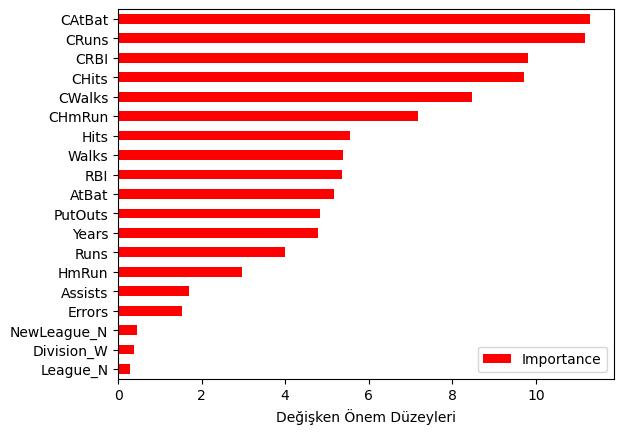

In [35]:
Importance.sort_values( by = "Importance",
                       axis = 0,
                       ascending = True).plot(kind = "barh", color = "r")

plt.xlabel("Değişken Önem Düzeyleri")